# TEST: ripulire gli spettri con un autoencoder

### Lettura dati

In [1]:
import numpy as np

# 1. Caricamento dati
f = np.arange(2500, 3250)
s_clean = np.load('../data/test/X_spectra.npy')
B = np.load('../data/test/Y_B_field.npy')

input_shape = s_clean.shape[1]

### Noising

In [2]:
from ml_odmr.noising import *

# 2. Aggiunta rumore
s_noisy = np.zeros_like(s_clean)
for i in range(s_clean.shape[0]):
    s_noisy[i] = add_poisson_noise(s_clean[i], scale=0.3)
    ''' 
    Per ora sospendo trend e outliers, perché una persona seria li eliminerebbe prima di fare qualsiasi analisi.
    Rimuoverli è semplicissimo, quindi sarebbe come non averli mai aggiunti.
    '''
    #s_noisy[i] = add_poly_trend(f, np.copy(s_clean[i]))
    #s_noisy[i] = add_poisson_noise(s_noisy[i], scale=0.3)
    #s_noisy[i] = add_outliers(s_noisy[i])

### Modello

In [3]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation, Input
from tensorflow.keras.constraints import max_norm # per il max-norm constraint

In [4]:
# 3. Costruzione del Modello
model = Sequential()

# ENCODER #
model.add(Input(shape=(input_shape,)))
model.add(Dense(64))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Dense(32))
model.add(BatchNormalization())
model.add(Activation('relu'))

# Bottleneck layer con max-norm constraint (es. valore max 3) #
model.add(Dense(8, name='bottleneck', kernel_constraint=max_norm(3)))
model.add(BatchNormalization())
model.add(Activation('relu'))

# DECODER #
model.add(Dense(32))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Dense(64))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Dense(input_shape))
model.add(Activation('linear')) # Linear è corretto per la regressione dei bin

# Compilazione
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        48,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 750)            │        48,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 750)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,358 (399.84 KB)

 Trainable params: 101,958 (398.27 KB)

 Non-trainable params: 400 (1.56 KB)

In [5]:
# 4. Fit del modello (Denoising)
# x = input rumoroso, y = target pulito
history = model.fit(
    x=s_noisy, 
    y=s_clean, 
    epochs=50,          # Sostituisci con il tuo no_epochs
    batch_size=32,      # Sostituisci con il tuo batch_size
    validation_split=0.2 # Usa il 20% dei dati per testare l'overfitting
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0556 - val_loss: 0.0279
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0261 - val_loss: 0.0265
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0213 - val_loss: 0.0248
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0183 - val_loss: 0.0228
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0165 - val_loss: 0.0210
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0160 - val_loss: 0.0193
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0142 - val_loss: 0.0174
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0138 - val_loss: 0.0157
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0128 - val_loss: 0.0143
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0126 - val_loss: 0.0131
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0115 - val_loss: 0.0116
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0114 - val_lo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


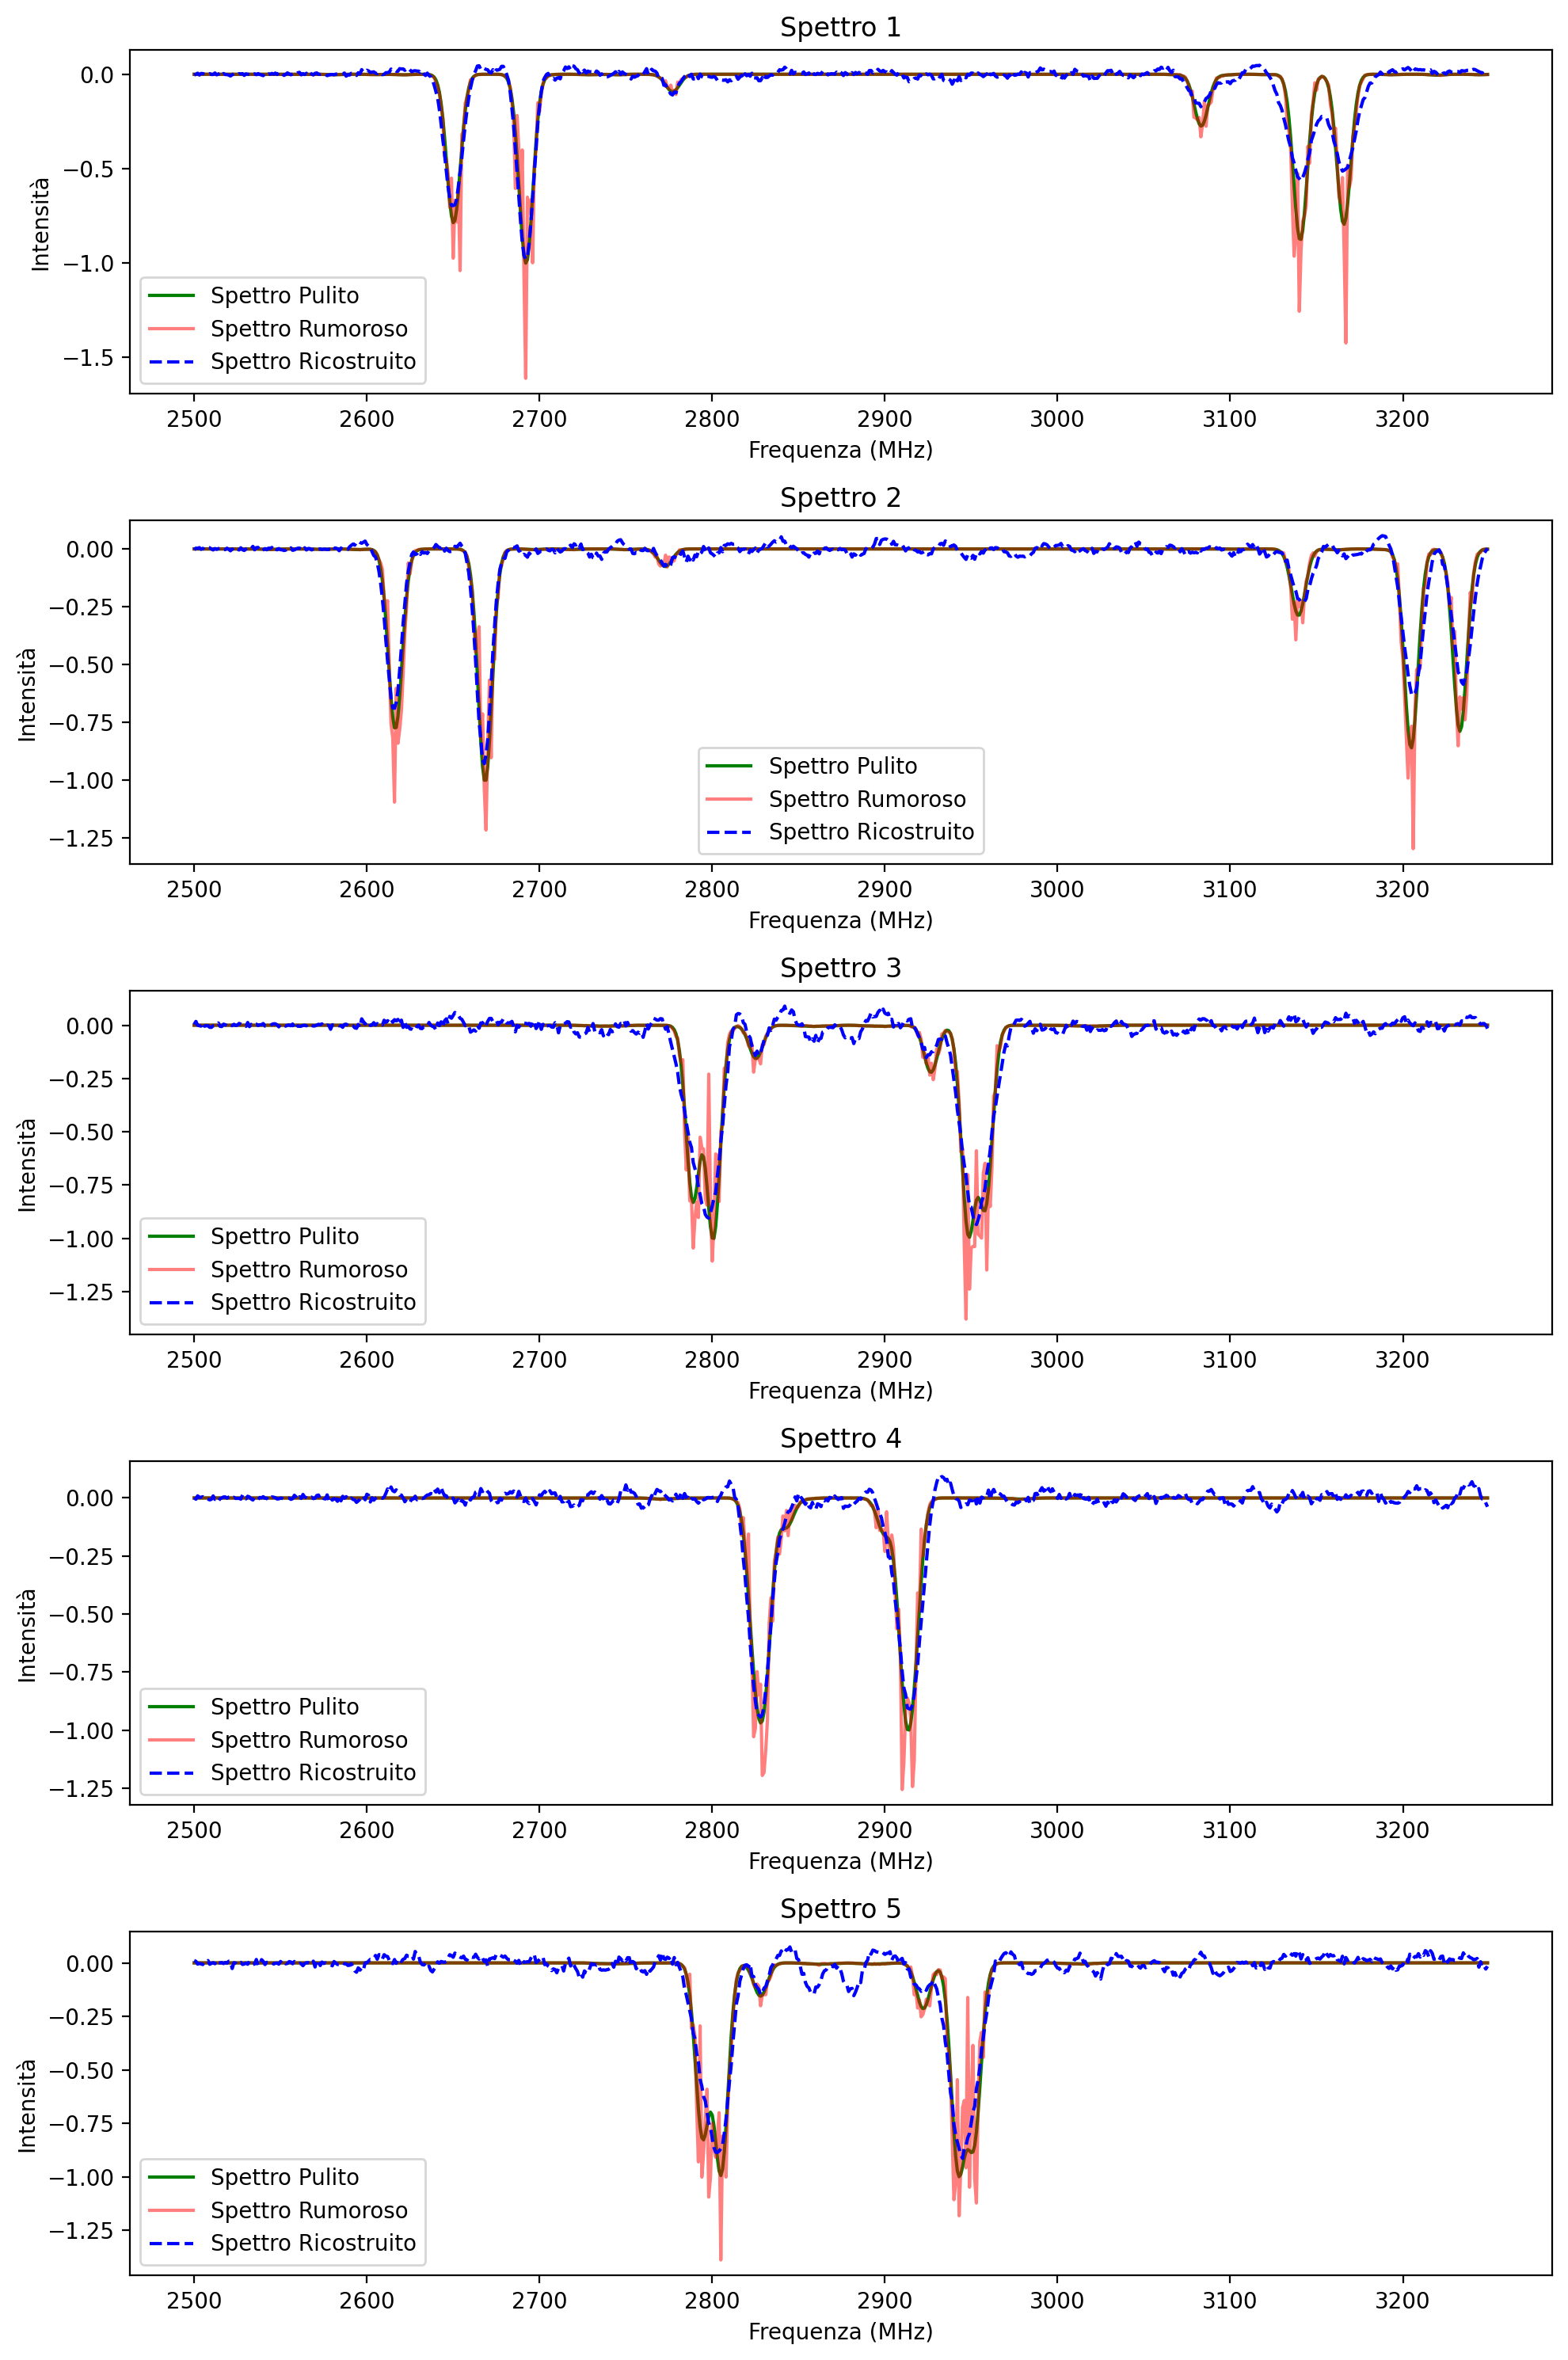

In [8]:
# 5. Ricostruzione (Previsione)
# Simuliamo di voler pulire i primi 5 spettri del nostro dataset
spettri_da_pulire = s_noisy[:5]
spettri_ricostruiti = model.predict(spettri_da_pulire)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 15), dpi=200)
for i in range(5):
    plt.subplot(5, 1, i+1)
    plt.plot(f, s_clean[i], label='Spettro Pulito', color='green')
    plt.plot(f, spettri_da_pulire[i], label='Spettro Rumoroso', color='red', alpha=0.5)
    plt.plot(f, spettri_ricostruiti[i], label='Spettro Ricostruito', color='blue', linestyle='dashed')
    plt.legend()
    plt.title(f'Spettro {i+1}')
    plt.xlabel('Frequenza (MHz)')
    plt.ylabel('Intensità')
plt.tight_layout()
plt.show()

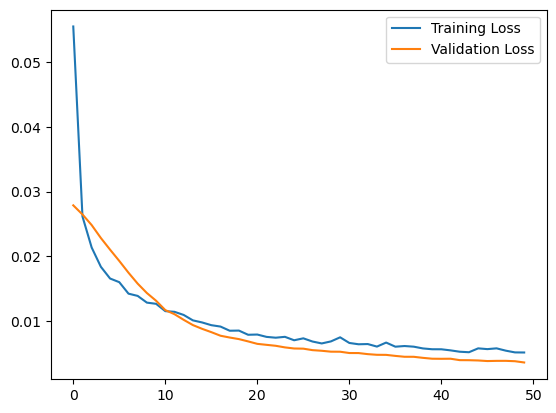

In [7]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()